# Estadistica descriptiva
### Estructuras de datos en Pandas

**Series** . Las series de Pandas son vectores similares a los arrays de NumPy, que podemos indexar usando etiquetas.

## Ejercicio 1
Crear la siguiente Series, observar que devuelve array e index e interpretar

In [3]:
import numpy as np
import pandas as pd
obj = pd.Series([7,4,-5,3])
display(obj)
display(obj.array)
display(obj.index) # Por default los indices van de 0 a n-1.

0    7
1    4
2   -5
3    3
dtype: int64

<NumpyExtensionArray>
[7, 4, -5, 3]
Length: 4, dtype: int64

RangeIndex(start=0, stop=4, step=1)

## Ejercicio 2
Podemos asignar etiquetas (o índices) a cada valor de la serie.

In [4]:
obj2 = pd.Series([np.pi,0,-2,1.41], index=['d','b','c','a'])
display(obj2)
display(obj2.array)
display(obj2.index)

d    3.141593
b    0.000000
c   -2.000000
a    1.410000
dtype: float64

<NumpyExtensionArray>
[3.141592653589793, 0.0, -2.0, 1.41]
Length: 4, dtype: float64

Index(['d', 'b', 'c', 'a'], dtype='str')

## Ejercicio 3
Al igual que con arrays de Numpy podemos acceder a los elementos por su posición , o podemos usar las etiquetas. Ejecutar los siguientes comandos:

In [5]:
print(obj2["a"])
# obj2[3] ésto no funca, ya que cambiamos las etiquetas
print(obj2[1:3])

obj3 = obj2 [["a","b"]]
print(obj3)
print(obj3.index)

print(obj2[obj2>1])

1.41
b    0.0
c   -2.0
dtype: float64
a    1.41
b    0.00
dtype: float64
Index(['a', 'b'], dtype='str')
d    3.141593
a    1.410000
dtype: float64


## Ejercicio 4
Las operaciones que pueden aplicarse a numpy arrays pueden aplicarse también a series de Pandas, conservando los índices.

In [6]:
np.exp(obj2)
obj2 * 3

d    9.424778
b    0.000000
c   -6.000000
a    4.230000
dtype: float64

## Ejercicio 5
### Métodos de series
Ejecutar los siguientes comandos e interpretar qué hace cada uno.


In [7]:
series1 = pd.Series(["a","b","c","b","a","c","c","x"])

In [8]:
series1.isin(["b","c"])

0    False
1     True
2     True
3     True
4    False
5     True
6     True
7    False
dtype: bool

In [9]:
series1.value_counts()

c    3
a    2
b    2
x    1
Name: count, dtype: int64

### DataFrames
Un DataFrame es una representación de los datos en formato de tabla donde las columnas son vectores del mismo tamaño. Como cada columna es un vector, cada columna puede contener datos de un único tipo. Se pueden pensar como variables. Cada variable corresponde a una serie de Pandas, y todas las series de un mismo DataFrame están indexadas por los mismos índices.

## Ejercicio 6 
Una forma de crear un DataFrame es utilizando un "diccionario". Todas las variables del diccionario deben ser vectores o listas de la misma longitud. Ejecutar el siguiente código.

In [10]:
data = {"nombre": ["Rodrigo", "Sergio", "Cristina", "Diana"] , "altura":
np . array ([178 , 172 , 175 , 168]) , "peso": np . array ([81.2 , 76.1 , 68.5 ,
64.0]) }
display ( data )

{'nombre': ['Rodrigo', 'Sergio', 'Cristina', 'Diana'],
 'altura': array([178, 172, 175, 168]),
 'peso': array([81.2, 76.1, 68.5, 64. ])}

In [11]:
pacientes = pd . DataFrame ( data ) . set_index ("nombre")
display ( pacientes )

,altura,peso
nombre,,
Rodrigo,178,81.2
Sergio,172,76.1
Cristina,175,68.5
Diana,168,64.0


## Ejercicio 7
¿ Cuál es la clase del objeto pacientes? ¿Cual es la clase de cada uno de los vectores columna? (Para saber la clase de un objeto, utilizar el comando _type_ , para saber el tipo de datos de un array de numpy , utilizar np.dtype)


In [12]:
type(pacientes)

pandas.DataFrame

In [13]:
np.dtype(pacientes["altura"])
np.dtype(pacientes["peso"])
# np.dtype(pacientes["nombre"]) . ¿Por qué no funciona ésto? Porque nombre no es una columna 

dtype('float64')

## Ejercicio 8
Guardar en una variable nueva el vector columna altura. Pueden utilizar pacientes["altura"] o pacientes.altura(Es preferible la primera para evitar errores en caso de que en la segunda el nombre coincida con alguna función ya existente)

In [14]:
altura = pacientes["altura"]
altura

nombre
Rodrigo     178
Sergio      172
Cristina    175
Diana       168
Name: altura, dtype: int64

## Ejercicio 9
A diferencia de las matrices en Numpy, un DataFrame de Pandas es un **Conjunto de columnas** , no de filas. Pensar cuál de los dos comandos será correcto antes de ejecutarlos.

In [15]:
#pacientes["Rodrigo"].altura
pacientes["altura"].Rodrigo

np.int64(178)

Wtf en serio es la segunda la que funciona?

Claro, porque de la columna "altura" agarra el índice Rodrigo. Recontra remil anti intuitivo

### loc e iloc
Para evitar confusones , un DataFrame tiene atributos _loc_ e _iloc_ para indexar por etiquetas o por índice respectivamente. 
Dado que un DataFrame tiene dos dimensiones, se puede seleccionar un subset de las filas y las columnas con notación numpy usando tanto las etiquetas de los ejes, o los enteros.

In [16]:
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                     index=["Ohio", "Colorado", "Utah", "New York"],
                     columns=["one", "two", "three", "four"])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [17]:
data.loc["Colorado"]

one      4
two      5
three    6
four     7
Name: Colorado, dtype: int64

In [18]:
data.loc[["Colorado","New York"]]

,one,two,three,four
Colorado,4,5,6,7
New York,12,13,14,15


In [19]:
data.iloc[1]

one      4
two      5
three    6
four     7
Name: Colorado, dtype: int64

In [20]:
data.loc["Colorado"].iloc[2] #De la fila "Colorado" le pido la columna del índice 2 (osea la tercera)

np.int64(6)

Así sí es intuitivo. Para mí por lo menos.

In [21]:
data.loc[["Colorado","Utah"]].iloc[1,[1,2]]

two       9
three    10
Name: Utah, dtype: int64

## Gapminder
## Ejercicio 10
A modo de ejemplo, vamos  aexplorar el DataFrame _gapmindeR_ que contiene datos poblacionales y de desarrollo humano de distintos países a lo largo del tiempo.
Cargar la biblioteca _gapminder utilizando.

In [22]:
#from gapminder import gapminder

Esta cagada de gapminder no anda

In [23]:
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

## Ejercicio 11 
¿De qué clase es el objeto gapminder?¿Qué variables tiene el DataFrame gapminder y de qué clase son?¿Qué índices usa?

In [24]:
gapminder.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   str    
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 80.0 KB


In [25]:
gapminder

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


## Ejercicio 12 
Explorar el tamaño del DataFrame _gapminder_ usando la función shape.

In [26]:
gapminder.shape

(1704, 6)

## Ejercicio 13
¿De cuántos países hay datos? Ayuda: Averiguar qué hacen los métodos _unique()_ y _nunique()_ aplicados a series

In [28]:
#unique() **Lista** la cantidad de elementos únicos. Lo que devuelve es un array de numpy. Sólo se puede aplicar a Series, incluye a NaN como valor único y los valores son retornados en orden de aparición
gapminder.country.unique()

<StringArray>
[       'Afghanistan',            'Albania',            'Algeria',
             'Angola',          'Argentina',          'Australia',
            'Austria',            'Bahrain',         'Bangladesh',
            'Belgium',
 ...
             'Uganda',     'United Kingdom',      'United States',
            'Uruguay',          'Venezuela',            'Vietnam',
 'West Bank and Gaza',         'Yemen Rep.',             'Zambia',
           'Zimbabwe']
Length: 142, dtype: str

In [29]:
#nunique() **Cuenta** la cantidad de elementos únicos. Por lo tanto devuelve un entero (o una serie de enteros) y se puede aplicar a Series y Dataframes. Excluye los NaN por default (salvo que pongamos dropna= False)
gapminder.country.nunique()

142

In [33]:
gapminder.nunique()

country       142
year           12
pop          1704
continent       5
lifeExp      1626
gdpPercap    1704
dtype: int64

In [34]:
gapminder.nunique().info() #fijate que ésto es una Serie

<class 'pandas.Series'>
Index: 6 entries, country to gdpPercap
Series name: None
Non-Null Count  Dtype
--------------  -----
6 non-null      int64
dtypes: int64(1)
memory usage: 268.0+ bytes


## Ejercicio 14
Extraer la información de Argentina, Uruguay y Chile y guardarla en un nuevo DataFrame gm_sur . Sugerencia : recordar el método isin()

In [39]:
auc = ['Argentina','Uruguay','Chile']
gm_sur = gapminder[gapminder['country'].isin(auc)]
gm_sur

,country,year,pop,continent,lifeExp,gdpPercap
48,Argentina,1952,17876956.0,Americas,62.485,5911.315053
49,Argentina,1957,19610538.0,Americas,64.399,6856.856212
50,Argentina,1962,21283783.0,Americas,65.142,7133.166023
51,Argentina,1967,22934225.0,Americas,65.634,8052.953021
52,Argentina,1972,24779799.0,Americas,67.065,9443.038526
53,Argentina,1977,26983828.0,Americas,68.481,10079.026740
54,Argentina,1982,29341374.0,Americas,69.942,8997.897412
55,Argentina,1987,31620918.0,Americas,70.774,9139.671389
56,Argentina,1992,33958947.0,Americas,71.868,9308.418710
57,Argentina,1997,36203463.0,Americas,73.275,10967.281950


¿Cuántas filas tiene? ¿Cuál es el primer y el último año para el cuál existen detos de Argentina en _gapminder_?

In [41]:
gm_sur.shape

(36, 6)

In [48]:
gm_sur[gm_sur['country'] == 'Argentina'].groupby('country')['year'].max()

country
Argentina    2007
Name: year, dtype: int64

In [47]:
gm_sur.groupby('country')['year'].min() #Y sin el filtro por país es así

country
Argentina    1952
Chile        1952
Uruguay      1952
Name: year, dtype: int64

## Ejercicio 15
¿Cómo está indexado el DataFrame gm_sur? Para acceder a una fila de un DataFrame, podemos usar los métodos loc[] e iloc[]. ¿Cómo se usan? ¿Cuál es la diferencia?

In [85]:
gm_sur.set_index('country', inplace=True)
# Está indexado por los *nombres de los países*
# Entonces para acceder a una fila podemos usar .loc[nombre_del_pais]
# ó iloc[indice_de_la_fila]

gm_sur.iloc[0]

year                1952
pop           17876956.0
continent       Americas
lifeExp           62.485
gdpPercap    5911.315053
Name: Argentina, dtype: object

In [86]:
gm_sur.loc['Argentina']

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Argentina,1952,17876956.0,Americas,62.485,5911.315053
Argentina,1957,19610538.0,Americas,64.399,6856.856212
Argentina,1962,21283783.0,Americas,65.142,7133.166023
Argentina,1967,22934225.0,Americas,65.634,8052.953021
Argentina,1972,24779799.0,Americas,67.065,9443.038526
Argentina,1977,26983828.0,Americas,68.481,10079.026740
Argentina,1982,29341374.0,Americas,69.942,8997.897412
Argentina,1987,31620918.0,Americas,70.774,9139.671389
Argentina,1992,33958947.0,Americas,71.868,9308.418710


## Archivos de datos
## Ejercicio 16
La biblioteca pandas nos permite también trabajar con archivos de datos.

(a) Leer el archivo casos_coronavirus.csv

(b) Graficar la curva de casos por día

(c) Graficar la curva de casos acumulados(utilizar la función cum_sum para calcularlos)

(d) Definir _y_ como el logaritmo de la cantidad de casos acumulados y graficar _y_ en función de la cantidad de días transcurridos.


Utilizar el siguiente código para leer el archivo y graficar.

In [60]:
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("datasets/casos_coronavirus.csv")
df

,fecha,confirmados_Nuevos
0,3-3-2020,1
1,4-3-2020,0
2,5-3-2020,1
3,6-3-2020,6
4,7-3-2020,0
...,...,...
91,2-6-2020,904
92,3-6-2020,949
93,4-6-2020,929
94,5-6-2020,840


<Axes: >

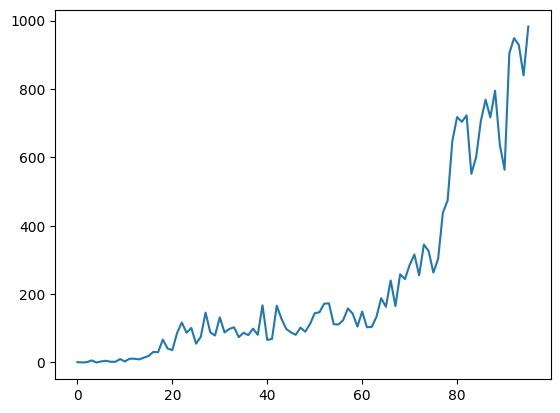

In [62]:
df["confirmados_Nuevos"].plot()

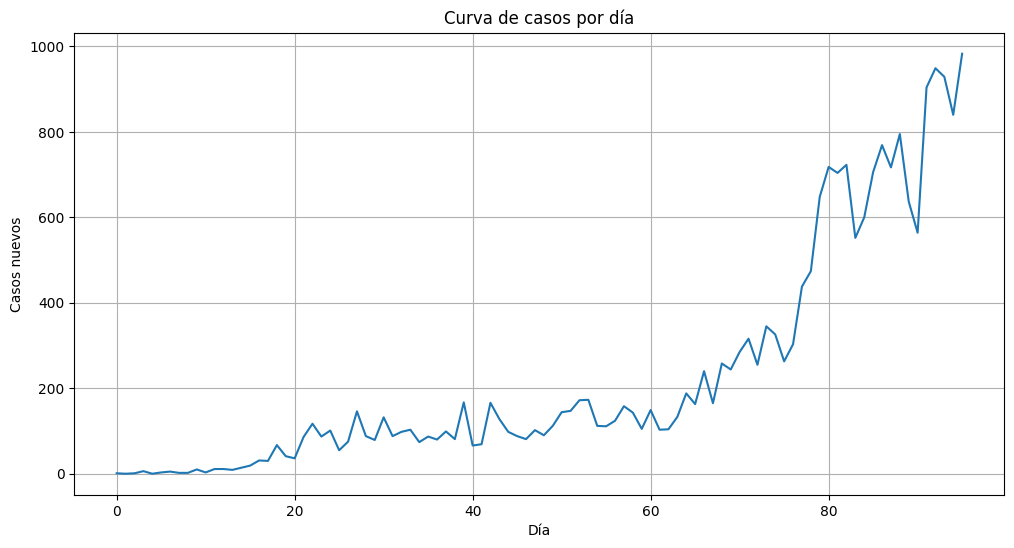

In [64]:
#Ésto queda mas fachero :p
plt.figure(figsize=(12, 6))
plt.plot(df["confirmados_Nuevos"])
plt.xlabel("Día")
plt.ylabel("Casos nuevos")
plt.title("Curva de casos por día")
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Curva de casos acumulados')

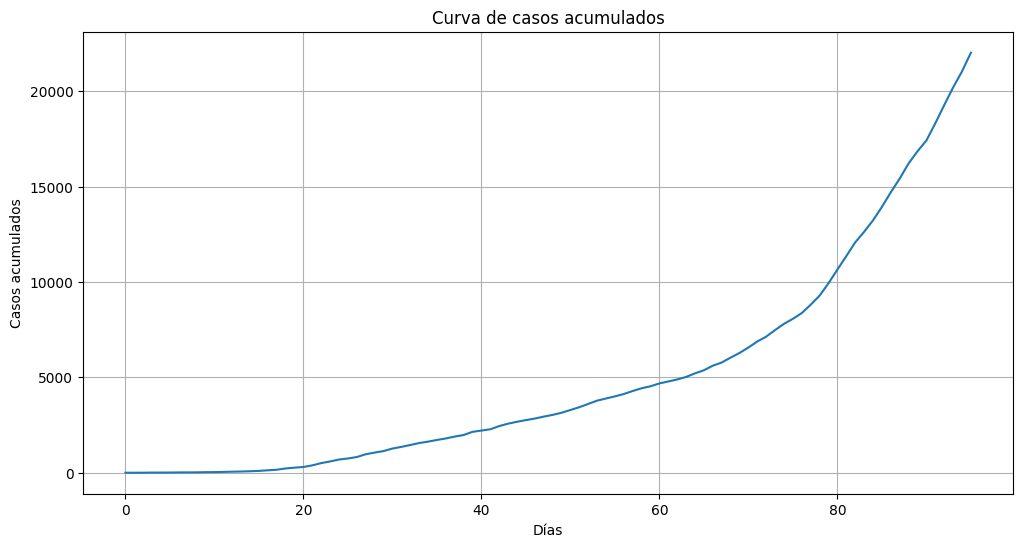

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(df["confirmados_Nuevos"].cumsum())
plt.xlabel("Días")
plt.ylabel("Casos acumulados")
plt.grid(True)
plt.title("Curva de casos acumulados")

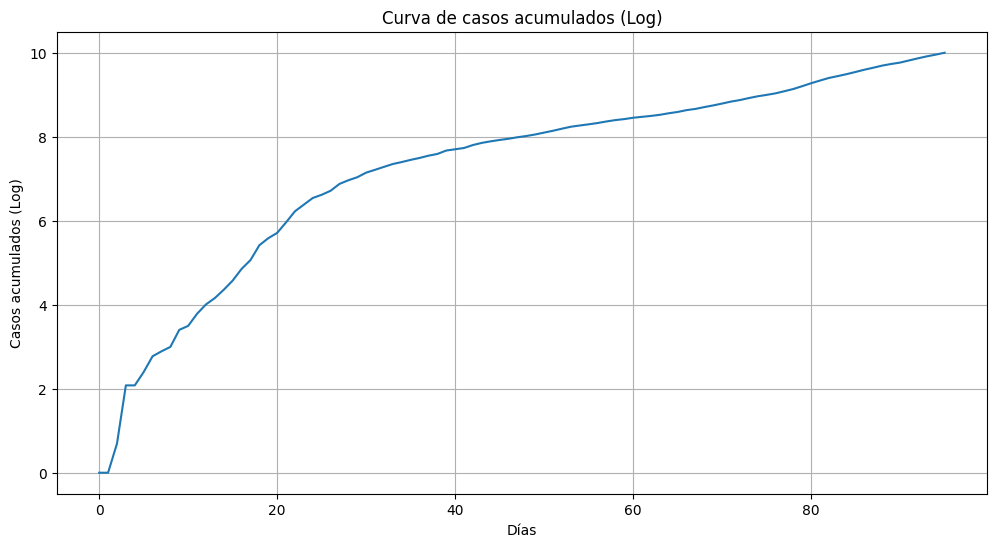

In [72]:
# Y nos va a servir para hacer mejor el ejercicio(d)
# definir y como el logaritmos de la cantidad de casos acumulados y graficar y en función de la cantidad de días transcurridos
plt.figure(figsize=(12, 6))
plt.plot(np.log(df["confirmados_Nuevos"].cumsum()))
plt.xlabel("Días")
plt.ylabel("Casos acumulados (Log)")
plt.title("Curva de casos acumulados (Log)")
plt.grid(True)

# Estadística descriptiva

### Variables Categóricas
Una variable categórica representa diferentes categorías o grupos. Pueden ser **nominales**(no tienen un orden intrínseco) u **Ordinales** (Sí tienen un orden intrínseco)

### Variables Numéricas
Son variables que representan cantidades numéricas. Las variables numéricas se pueden dividir en dos tipos : **discreta** y **continua**

- **Discreta**: Representa valores contables y no puede tomar valores intermedios
- **Continua**: Representa medidas y puede tomar cualquier valor dentro de un rango.


## Ejercicio 17
Dar 3 ejemplos de variables categóricas y numéricas.

### Ejemplos de categórica
#### Nominal : 
- Marcas de auto : 
    - Chevrolet
    - Ford
    - Fiat
    - Citroen
- Animales:
    - Perro
    - Gato
    - Lobo marino
    - Ballena
- Los Joestars:
    - Jonathan
    - Jolyne
    - Josuke
    - Joseph
    - Jotaro
    - Johnny
    - Gappy
    - Jodio
    - Giorno (Mención honorífica, es Giovanna no Joestar)


#### Ordinal:
- Fases del torneo:
    1. Fase de grupos
    2. Octavos de final
    3. Cuartos de final
    4. Semis
    5. Final
- Las montañas más altas sobre el nivel del mar:
    1. Monte Everest
    2. K2
    3. Kangchenjunga (xd)
    4. Lhotse
    5. Están todas en el Himalaya un embole
    6. Cerro Aconcagua
- Las partes de JoJos:
    1. Phantom Blood
    2. Battle Tendency
    3. Stardust Crusaders
    4. Diamond is Unbreakable
    5. Vento Aureo
    6. Stone Ocean
    7. STEEL BALL RUUUUUUUN
    8. Jojolion
    9. The JOJOLands

### Ejemplos de numérica
### Discreta : 
- Años :
    - 2000
    - 2001
    - 2002
    - 2003
- Cantidad de autos por cochera:
    - 12
    - 15
    - 8
    - 1
- Cantidad de núcleos del procesador:
    - 2
    - 4
    - 8 
    - 16
### Continua : 
- Altura (en metros)
    - 1.60
    - 1.75
    - 1.82
    - 1.68
- Tiempo por vuelta (en segundos)
    - 52.7
    - 55.8
    - 50.1
- Peso (en Kg)
    - 65.7
    - 90.2
    - 37.5
    - 82.01

## Ejercicio 18 
En el DataFrame _gapminder_ ,una de las variables es el producto bruto per cápita de los países (gdpPercap). ¿Es una variable categórica (nominal u ordinal) o numérica (discreta o continua)?

In [73]:
gapminder

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


Parece ser una variable numérica continua

## Ejercicio 19
Supongamos que definimos una nueva variable que puede tomar los siguientes valores:

nivelGDP = {

        0 si gdpPercap <1600 ,
        
        1 si 1600 <= gdpPercap < 6600
        
        2 en otro caso.
}

¿La nueva variable es categórica (nominal u ordinal) o númerica (discreta o continua)? ¿Cambia la respuesta si la variable toma valores "bajo","medio" y "alto" en lugar de 0,1,2?

Ahora la variable es categórica ordinal :)

Mi razonamiento para decir que deja de ser numérica, es que estamos agrupando en categorías. En lugar de ser enteros podríann haber sido "Grupo pepito" "Grupo simon" "Grupo grupete".

Con ese criterio, si tomara valores "bajo", "medio" y "alto" la respuesta sería la misma

## Ejercicio 20
Filtrar el DataFrame de _gapminder_ para el año 2007. Luego para ese año calcular la cantidad de países en cada continente. Explorar la función groupBy() y los métodos size y nunique() de un dataframe agrupado.

In [74]:
gapminder

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


In [80]:
gapminder[gapminder['year'].isin([2007])]

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [81]:
gapminder.groupby('year').filter(lambda x: x['year'].iloc[0] == 2007)

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


## Ejercicio 21
Con el mismo filtro que el ejercicio anterior, crear una variable _gdpAlto_ que valga 1 si _gdpPercap_ es mayor que 2000 dólares y 0 si no lo es. Luego crear una tabla de 2 filas y 5 columnas que calcule la cantidad de países donde _gdpAlto_ = 0 o _gdpAlto_ = 1 en cada continente.

Ayuda 1 : para convertir un array de variables booleanas a 0/1 pueden usar .astype(int) (o en éste ejercicio pueden usar una variable booleana en vez de 0/1)

Ayuda 2 : Si tenemos unformación agrupada por 2 columnas, podemos convertirla a una tabla con la función unstack().

In [ ]:
gdpAlto = gapminder.groupby('year').filter(lambda x: x['year'].iloc[0] == 2007) # Creo el filtro
gdpAlto['gdpAlto'] = (gdpAlto['gdpPercap'] > 2000).astype(int) #Una vez filtrado, coloco un 1 en cada país que tenga un gdpPercap mayor a 2000, y un 0 en el resto.
gdpAlto 

tabla = gdpAlto.groupby(['continent','gdpAlto']).size().unstack('gdpAlto') # Ojo , acá necesito pasarle gdpAlto porque quiero contar la cantidad de países con gdpAlto que haya en cada continente.
tabla.T  # La traspongo para que quede de 2 filas y 5 columnas

continent,Africa,Americas,Asia,Europe,Oceania
gdpAlto,,,,,
0,33.0,1.0,6.0,NaN,NaN
1,19.0,24.0,27.0,30.0,2.0


## Ejercicio 22
En el gráfico vemos 11 puntos. Consideramos la media y mediana de la coordenada x de esos puntos y graficamos dos rectas verticales x = media y x = mediana. ¿ Cuál recta corresponde a la media y cuál a la amediana?

### Media :
Es el promedio de un conjunto de datos y se calcula sumando todos los valores y dividiéndolos por el número total de valores.

### Mediana:
Es el valor del medio cuando un conjunto de datos se ordena de menor a mayor. Si hay una cantidad par de datos, se toma el promedio entre los dos valores del medio.

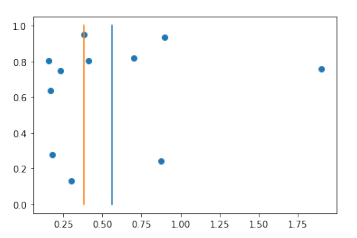